In [80]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import glob
import gzip
import pandas as pd

In [74]:
def extract_data_by_type(filenames, skip_timesteps=0):
    """
    Extracts data by particle type (with four particle types) from LAMMPS trajectory files

    Parameters
    filenames=Path(s) to the LAMMPS trajectory file(s).
    skip_timesteps=Number of timesteps at the beginning of each file to skip for equilibriation.

    Returns
    Tuple of arrays (type1, type2, type3, type4), where each array has shape
    (n_timesteps, n_atoms_species, 8) with values [type, q, x, y, z, vx, vy, vz],
    ordered by atom id within each timestep.
    """
    if isinstance(filenames, str):
        filenames = [filenames]

    all1 = []
    all2 = []
    all3 = []
    all4 = []

    timestep_data = []
    collect = False
    timestep_count = -1

    def finalize_timestep():
        """Store one timestep worth of data, split by charge."""
        if not timestep_data:
            return

        step_array = np.array(timestep_data, dtype=float)

        # Split by charge
        d1 = step_array[step_array[:, 0] == 1]
        d2  = step_array[step_array[:, 0] == 2]
        d3 = step_array[step_array[:, 0] == 3]
        d4  = step_array[step_array[:, 0] == 4]

        # Sort by atom id
        if len(d1) > 0:
            d1 = d1[d1[:, 0].argsort()]
        if len(d2) > 0:
            d2 = d2[d2[:, 0].argsort()]
        if len(d3) > 0:
            d3 = d3[d3[:, 0].argsort()]
        if len(d4) > 0:
            d4 = d4[d4[:, 0].argsort()]

        all1.append(d1)
        all2.append(d2)
        all3.append(d3)
        all4.append(d4)

        timestep_data.clear()

    for filename in filenames:
        open_func = gzip.open if filename.endswith(".gz") else open

        with open_func(filename, "rt") as f:
            for line in f:
                if line.startswith("ITEM: TIMESTEP"):
                    timestep_count += 1
                    if timestep_count >= skip_timesteps:
                        collect = True
                        finalize_timestep()
                    else:
                        collect = False
                    continue

                if collect and not line.startswith("ITEM"):
                    parts = line.strip().split()
                    if len(parts) == 12:  # format: type q x y z vx vy vz
                        type = int(parts[1])
                        q = float(parts[2])
                        x = float(parts[3])
                        y = float(parts[4])
                        z = float(parts[5])
                        vx = float(parts[6])
                        vy = float(parts[7])
                        vz = float(parts[8])
                        timestep_data.append([type, q, x, y, z, vx, vy, vz])

    # Save the final timestep
    finalize_timestep()

    return np.array(all1, dtype=float), np.array(all2, dtype=float), np.array(all3, dtype=float), np.array(all3, dtype=float)

In [267]:
files = glob.glob('../../New Diodes/SML/0.25_e60_L15_E0.05_faster_As_*_*_*_*_*_*_*_*/all.lammpstrj.gz')
n_files = len(files)
print(files)
Ts = np.linspace(0, 800, 801)
I_all = np.zeros((n_files, 801))
E_all = np.zeros((n_files, 801))
print(E_all.shape)
for j, file in enumerate(files):
    As = np.zeros(8)
    parts = file.split('_')
    sub_parts = parts[-1].split('\\')
    As[-1]=sub_parts[0]
    As[:-1] = parts[-8:-1]
    Xs = Ts/400-1
    E_all[j,:] = 0.05*(As[1]*np.cos(2*np.pi*5*As[0]*Xs)+As[3]*np.sin(2*np.pi*5*As[2]*Xs)+As[4]+As[5]*(Xs)+As[6]*(Xs)**2+As[7]*(Xs)**3)
    data1, data2, data3, data4 = extract_data_by_type(file)
    I_all[j,:] = np.mean(data1[:,:,7], axis=1)-np.mean(data3[:,:,7], axis=1) # cations - anions
    if j%10:
        print(f'{j}th file complete')

['../../New Diodes/SML\\0.25_e60_L15_E0.05_faster_As_0.0012_0.3395_0.6729_0.6023_0.3564_0.7458_0.2742_0.0171\\all.lammpstrj.gz', '../../New Diodes/SML\\0.25_e60_L15_E0.05_faster_As_0.0252_0.2506_0.4064_0.3639_0.1890_0.7898_0.7463_0.1230\\all.lammpstrj.gz', '../../New Diodes/SML\\0.25_e60_L15_E0.05_faster_As_0.0263_0.5984_0.4886_0.8255_0.4523_0.4891_0.4724_0.2855\\all.lammpstrj.gz', '../../New Diodes/SML\\0.25_e60_L15_E0.05_faster_As_0.0600_0.1104_0.3103_0.3486_0.7719_0.5988_0.7703_0.8450\\all.lammpstrj.gz', '../../New Diodes/SML\\0.25_e60_L15_E0.05_faster_As_0.0618_0.8838_0.7994_0.8053_0.7266_0.8735_0.8278_0.6451\\all.lammpstrj.gz', '../../New Diodes/SML\\0.25_e60_L15_E0.05_faster_As_0.0785_0.7303_0.4259_0.4790_0.1705_0.9521_0.9367_0.9690\\all.lammpstrj.gz', '../../New Diodes/SML\\0.25_e60_L15_E0.05_faster_As_0.0983_0.6781_0.9412_0.3025_0.1325_0.8449_0.7997_0.7908\\all.lammpstrj.gz', '../../New Diodes/SML\\0.25_e60_L15_E0.05_faster_As_0.1004_0.4812_0.5236_0.2231_0.4127_0.2311_0.6891_0.

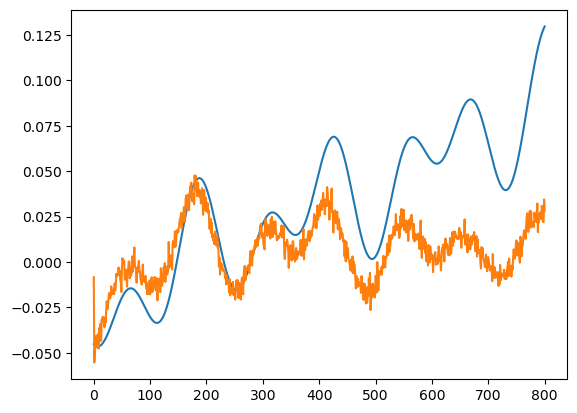

In [275]:
plt.plot(Ts, E_all[40,:])
plt.plot(Ts, I_all[40,:])

In [277]:
I_df = pd.DataFrame(I_all.T)
I_df.to_csv('../../New Diodes/SML/current.csv')
E_df = pd.DataFrame(E_all.T)
E_df.to_csv('../../New Diodes/SML/efield.csv')

In [284]:
I_all_spline = np.zeros_like(I_all)
Xs = Ts/400-1
for i in range(100):
    spl = scipy.interpolate.make_smoothing_spline(Xs, I_all[i,:])
    I_all_spline[i,:]=spl(Xs)

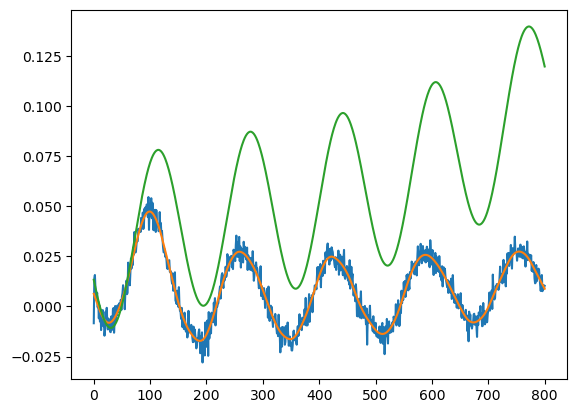

In [294]:

plt.plot(I_all[2,:])
plt.plot(I_all_spline[2,:])
plt.plot(E_all[2,:])

In [290]:
I_spline_df = pd.DataFrame(I_all_spline.T)
I_spline_df.to_csv('../../New Diodes/SML/current_splined.csv')